<a href="https://colab.research.google.com/github/joannabidenam/Machine-learning-linear-and-logistics-projects-/blob/main/Machine_learning__Linear_and_Logistics_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data source: https://www.kaggle.com/datasets/codebreaker619/salary-data-with-age-and-experience?resource=download (Kaggle)

In [189]:
import pandas as pd

from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/Salary_Data.csv')
df

,YearsExperience,Age,Salary
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891
5,2.9,23.0,56642
6,3.0,23.0,60150
7,3.2,23.3,54445
8,3.2,23.3,64445
9,3.7,23.6,57189


In [190]:
# Independent variable
X=df[['YearsExperience','Age']]

# Dependent variable
y=df['Salary']

In [191]:
model=LinearRegression()

model.fit(X,y) #Training the model

q=[[0,21],[5,30],[10,35]] #3 Examples of predicting salary based on experience and age

model.predict(q)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 31894.29828066,  79185.18713624, 119132.02161477])

In [192]:
model.score(X,y) #accuraty score of the model

0.9599822609873284

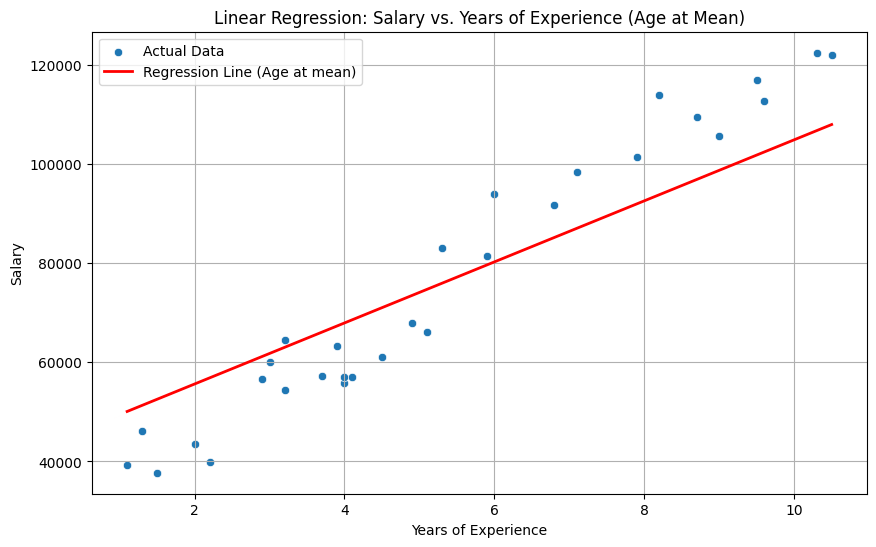

In [193]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a scatter plot of YearsExperience vs Salary
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, label='Actual Data')

sns.lineplot(x=x_exp, y=y_pred, color='red', label='Regression Line (Age at mean)', linewidth=2)

plt.title('Linear Regression: Salary vs. Years of Experience (Age at Mean)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

Data source: https://www.kaggle.com/code/monukhan/predict-person-purchased-the-product-or-not/input
(Kaggle)

In [194]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('/content/Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [195]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
# Logistic regression cannot handle strings so i have to convert Gender into numerical values

In [196]:
# Independent variables
X = df[['Gender', 'Age', 'EstimatedSalary']]

# Dependent variable
y = df['Purchased']
X


,Gender,Age,EstimatedSalary
0,0,19,19000
1,0,35,20000
2,1,26,43000
3,1,27,57000
4,0,19,76000
...,...,...,...
395,1,46,41000
396,0,51,23000
397,1,50,20000
398,0,36,33000


In [197]:
model=LogisticRegression()

model.fit(X,y) #Training the model

q=[[0,21,34600],[1,27,34600],[0,50,60000]] #3 Examples of predicting a purchase based on the gender, age and salary (0=Male, 1=Female)

model.predict(q)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0, 0, 1])

In [198]:
model.score(X,y) #accuraty score of the model

0.8525

/tmp/ipykernel_7931/2418235385.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Age', 'EstimatedSalary']] = scaler.fit_transform(X[['Age', 'EstimatedSalary']])


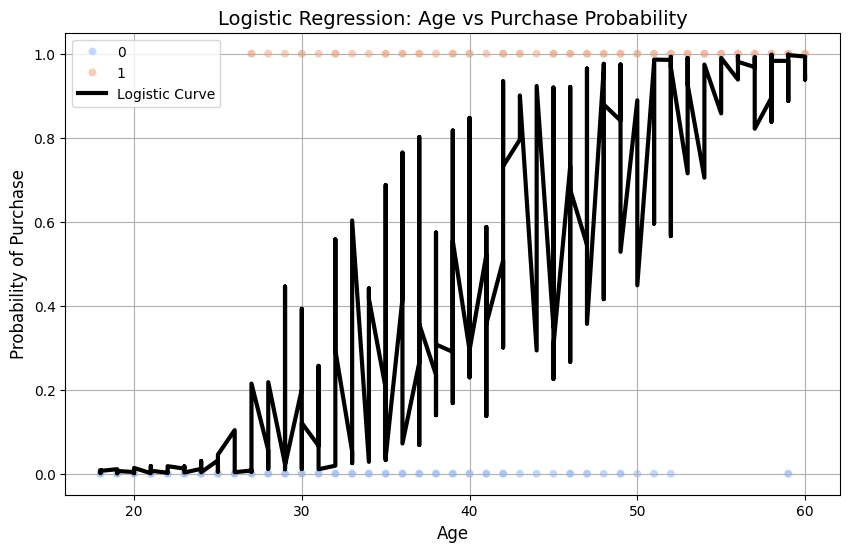

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# Scale Age and Salary
scaler = StandardScaler()
X[['Age', 'EstimatedSalary']] = scaler.fit_transform(X[['Age', 'EstimatedSalary']])

# Train model
model.fit(X, y)

# Get predicted probabilities
df['prob'] = model.predict_proba(X)[:,1]

# Sort by Age for smooth curve
df_sorted = df.sort_values('Age')

# Plot
plt.figure(figsize=(10,6))

# Scatter (actual data)
sns.scatterplot(
    x='Age',
    y='Purchased',
    data=df,
    hue='Purchased',   # adds color
    palette='coolwarm',
    alpha=0.7
)

# Logistic curve
plt.plot(
    df_sorted['Age'],
    df_sorted['prob'],
    color='black',
    linewidth=3,
    label='Logistic Curve'
)

# Styling
plt.title('Logistic Regression: Age vs Purchase Probability', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Probability of Purchase', fontsize=12)

plt.legend()
plt.grid(True)

plt.show()
